In [71]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_time(file_path, title_prefix='Union'):
    # Load the data
    data = pd.read_csv(file_path)
    data.head()
    data['average'] = data.groupby(['UnionSize', 'Weighted'])['Time'].transform('mean')
    data['std'] = data.groupby(['UnionSize', 'Weighted'])['Time'].transform('std')
    data['max'] = data.groupby(['UnionSize', 'Weighted'])['Time'].transform('max')
    # Set the style
    sns.set_style("whitegrid")

    # Create the plot
    plt.figure(figsize=(12, 8))
    # 使用hue='Weighted'，注意Weighted是0和1，可能会被当作连续值，所以我们将其转换为类别变量
    data['Weighted'] = data['Weighted'].astype(str)
    sns.lineplot(data=data, x='UnionSize', y='average', hue='Weighted', marker='o')
    
    # 为了填充标准差，我们需要分别处理每个组
    # 我们可以使用循环来分别绘制每个组的填充
    for weighted in data['Weighted'].unique():
        subset = data[data['Weighted'] == weighted]
        plt.fill_between(subset['UnionSize'], subset['average'] - subset['std'], subset['average'] + subset['std'], alpha=0.2)
    
    # 设置标签和标题
    plt.xlabel('Union Size')
    plt.ylabel('Time (seconds)')
    plt.title(f'{title_prefix} Performance: Weighted vs Unweighted')
    plt.legend(title='Weighted', labels=['Yes', 'YesStd','No', 'NoStd'])
    # Show the plot
    plt.show()

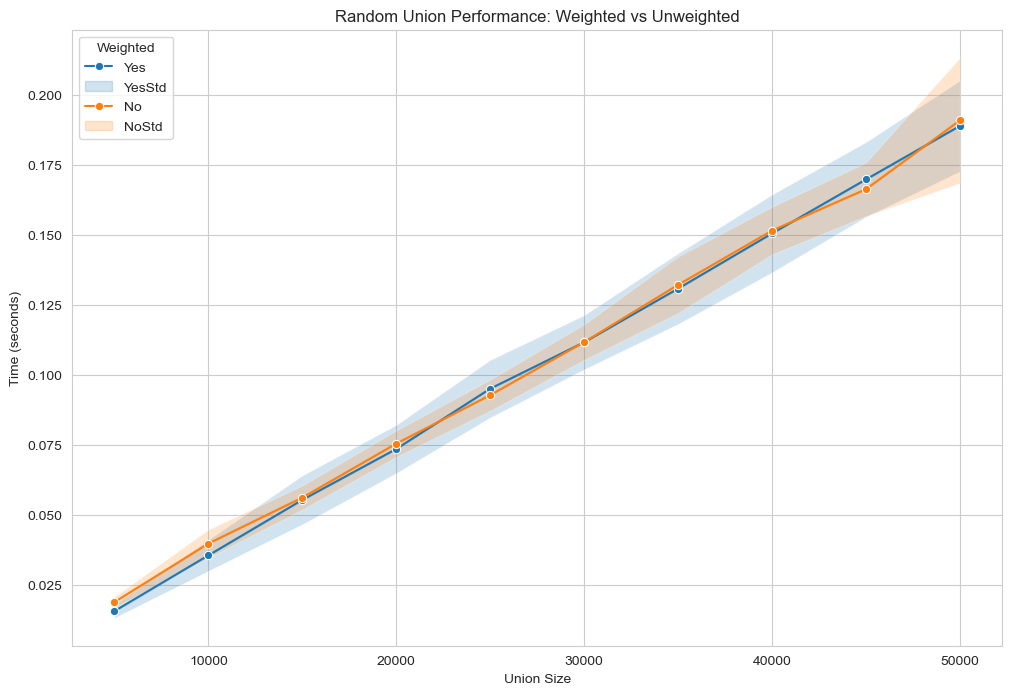

In [72]:
plot_time('data/random_union_results.csv', title_prefix='Random Union')

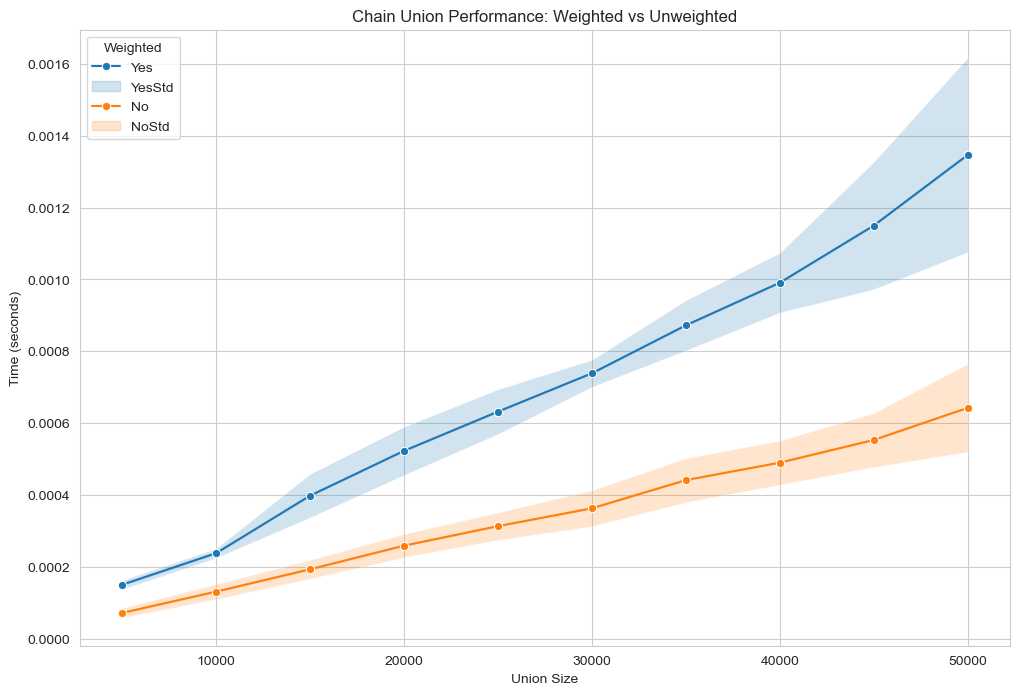

In [73]:
plot_time('data/chain_union_results.csv', title_prefix='Chain Union')

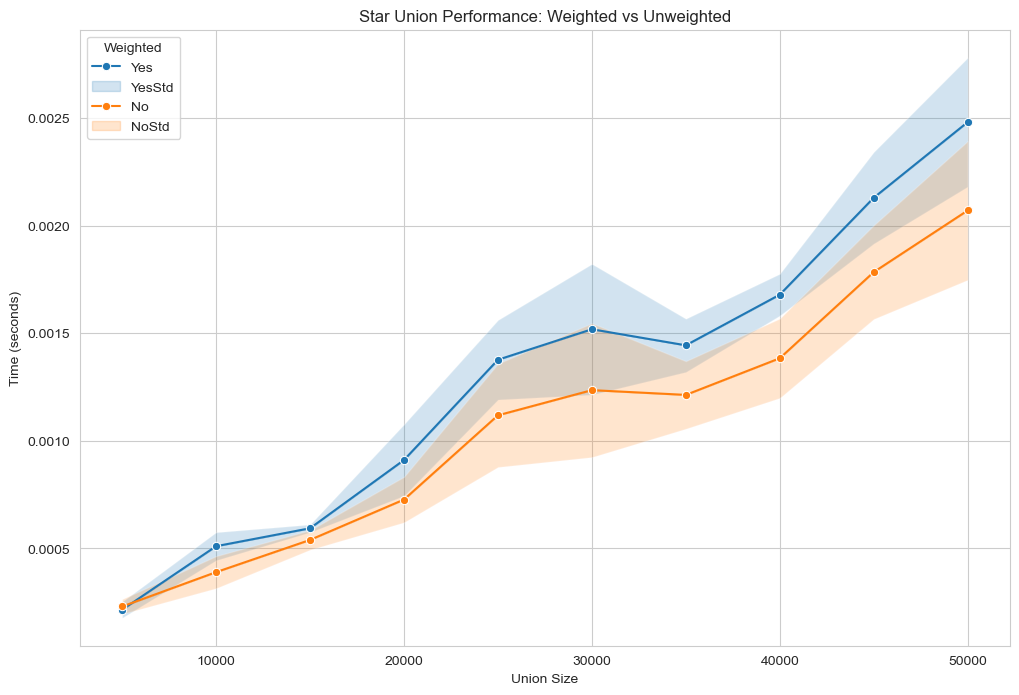

In [74]:
plot_time('data/star_union_results.csv', title_prefix='Star Union')

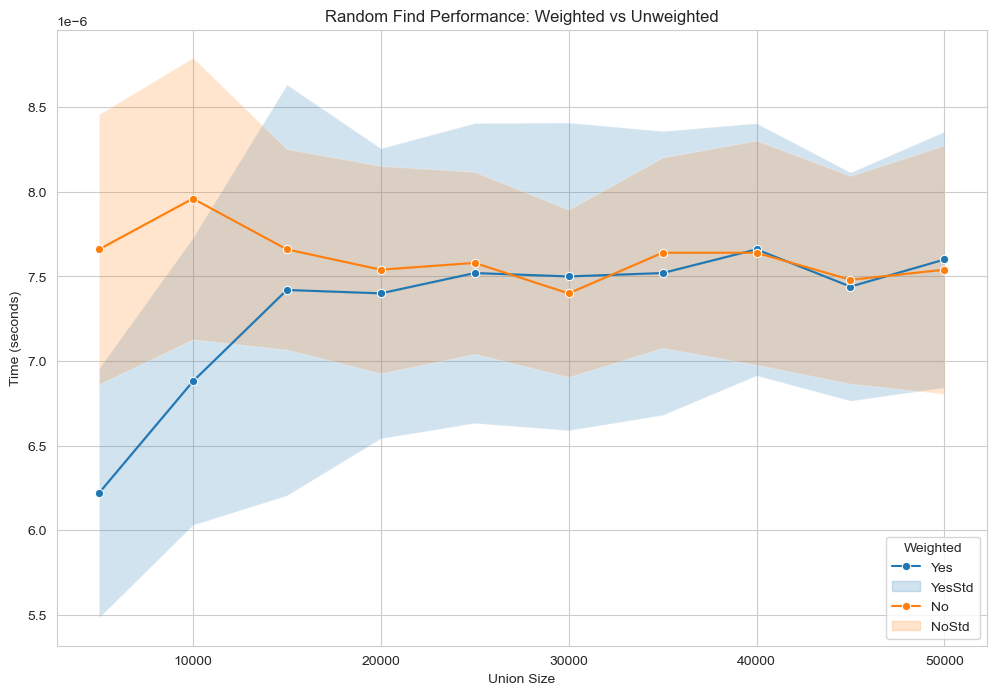

In [75]:
plot_time('data/random_find_results.csv', title_prefix='Random Find')

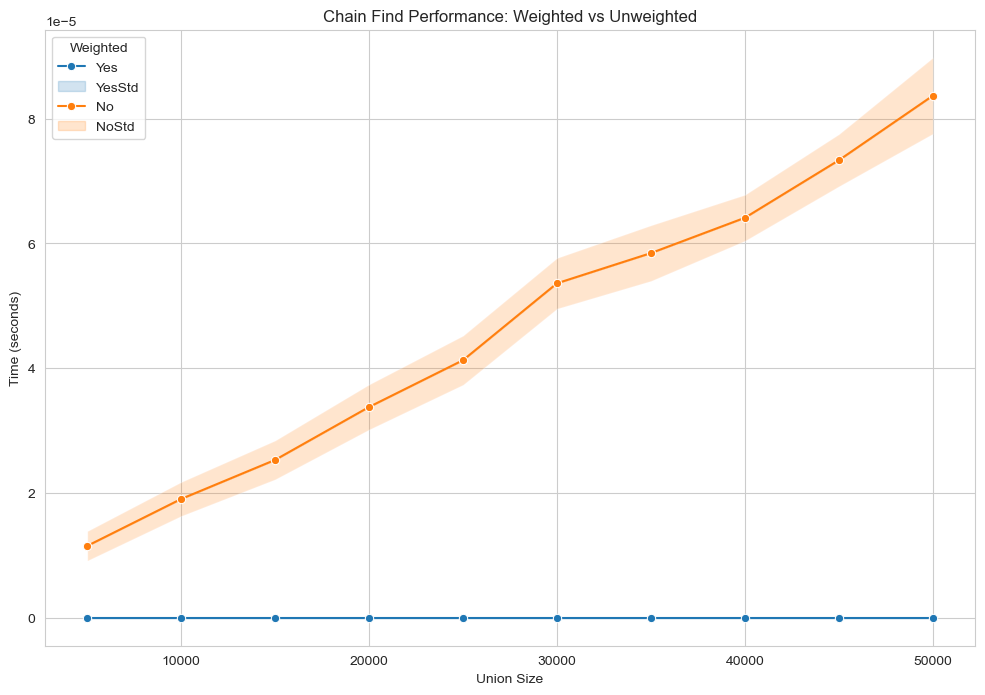

In [76]:
plot_time('data/chain_find_results.csv', title_prefix='Chain Find')

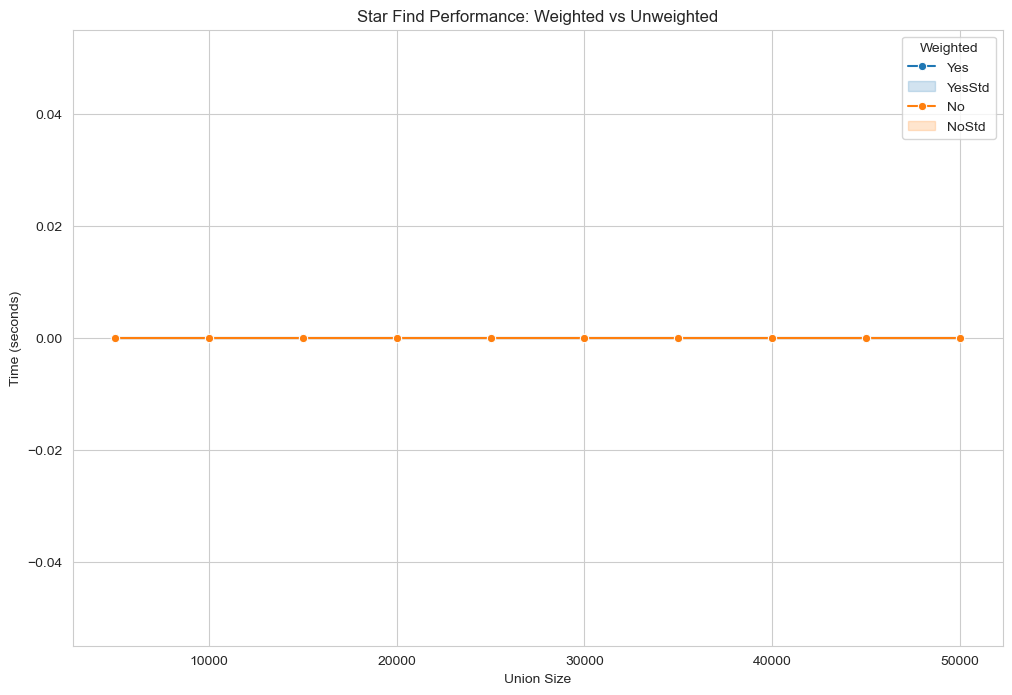

In [77]:
plot_time('data/star_find_results.csv', title_prefix='Star Find')